# Traffic-regime pruning: corridor vs open water

**What this measures.** For query regions in *dense corridors* versus *sparse open water*, what
share of the tiled table's bytes a file-level pruner must still read. It reuses the exact
from-metadata method of `experiments/evaluation/scripts/tile_size_model.py`, only the L0 sidecar bounds
(`xmin/xmax/ymin/ymax`) and each segment's trajectory-blob size, so it needs **no MobilityDuck
and no rebuild**, and the result is independent of the DuckDB version.

**Scope.** This is the *pruning* (bytes-read) side only, the "~20x fewer bytes"
claim. It does **not** recompute recall per regime (that needs the exact MEOS predicate on the
decoded trajectory, i.e. the full pipeline).

Run this from `benchmark/` with DuckDB 1.4.x.

> **This notebook ESTIMATES pruning from stored bounds: it does not run the queries.** It computes, from each L0 segment's bounding box, what share of the tiled table a query touching a region *would* read; it never decodes a trajectory or executes `eIntersects`/`atStbox`, and it measures no runtime or recall. To actually *run* the windowed query on these boxes over the real layouts with MEOS (real files/rows/bytes-read + runtime + vessel count), use **regime_queries.ipynb**, it needs the MobilityDuck extension + MinIO + the Iceberg catalog, so it needs the full stack. As a metadata estimate this is a weak signal; the execution version is what carries weight.

In [1]:
import os, json
import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# ---- config -------------------------------------------------------------
L0_GLOB   = "data/trips/L0/L0/**/*.parquet"   # the local L0 layer
TILE_M    = 50_000        # spatial tiling of the L2/L3 layout (main benchmark)
QUERY_BOX = 10_000        # side of the fixed "small local query" box (m) for the scatter

# corridor query regions (EPSG:32632 m), from lakehouse.query.registry
CORRIDOR = {
    "rodby (port)":      (651135.0, 6058230.0, 651422.0, 6058548.0),
    "puttgarden (port)": (644339.0, 6042108.0, 644896.0, 6042487.0),
    "goteborg (port)":   (666538.0, 6392057.0, 679171.0, 6403745.0),
    "belt (corridor)":   (640730.0, 6042487.0, 654100.0, 6058230.0),
}
# open-water query regions (belt-sized boxes off the traffic heatmap)
OPEN_WATER = {
    "north_sea_west":  (242631.9, 6183191.2, 256001.9, 6198934.2),
    "north_sea_south": (266695.5, 6036920.7, 280065.5, 6052663.7),
    "skagerrak_open":  (510998.3, 6432011.4, 524368.3, 6447754.4),
    "kattegat_open":   (628377.8, 6267154.9, 641747.8, 6282897.9),
}
con = duckdb.connect(); con.execute("PRAGMA threads=4")
print("duckdb", duckdb.__version__)

duckdb 1.4.4


## 1. Load L0 bounds and model the 50 km tiling

In [2]:
con.execute(f'''CREATE OR REPLACE TEMP TABLE bounds AS
  SELECT octet_length(traj) AS w, xmin,xmax,ymin,ymax,
         (xmin+xmax)/2.0 AS cx0, (ymin+ymax)/2.0 AS cy0
  FROM read_parquet('{L0_GLOB}') WHERE xmin IS NOT NULL''')
N_SEG, W_SEG = con.execute("SELECT count(*), sum(w) FROM bounds").fetchone()

# incidence of each segment into every TILE_M cell its bbox overlaps (what L2/L3 stores)
con.execute(f'''CREATE OR REPLACE TEMP TABLE incid AS
  SELECT w, gx.cx AS cx, gy.cy AS cy FROM bounds,
    LATERAL UNNEST(generate_series(CAST(floor(xmin/{TILE_M}) AS BIGINT),CAST(floor(xmax/{TILE_M}) AS BIGINT))) AS gx(cx),
    LATERAL UNNEST(generate_series(CAST(floor(ymin/{TILE_M}) AS BIGINT),CAST(floor(ymax/{TILE_M}) AS BIGINT))) AS gy(cy)''')
W_INC = con.execute("SELECT sum(w) FROM incid").fetchone()[0]
print(f"L0 segments: {N_SEG:,}   trajectory bytes: {W_SEG/1e9:.2f} GB")
print(f"tiled bytes @ {TILE_M//1000} km: {W_INC/1e9:.2f} GB  ({W_INC/W_SEG:.2f}x replication)")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

L0 segments: 381,713   trajectory bytes: 7.35 GB
tiled bytes @ 50 km: 49.27 GB  (6.70x replication)


## 2. Candidate byte-share per query region (corridor vs open water)

In [3]:
def candidate_share(x0,y0,x1,y1):
    cx0,cx1=int(x0//TILE_M),int(x1//TILE_M); cy0,cy1=int(y0//TILE_M),int(y1//TILE_M)
    tw,tc=con.execute(f"SELECT COALESCE(sum(w),0),count(DISTINCT (cx,cy)) FROM incid "
                      f"WHERE cx BETWEEN {cx0} AND {cx1} AND cy BETWEEN {cy0} AND {cy1}").fetchone()
    return 100.0*tw/W_INC, int(tc)
def local_density(x0,y0,x1,y1):
    return con.execute(f"SELECT count(*) FROM bounds WHERE cx0 BETWEEN {x0} AND {x1} "
                       f"AND cy0 BETWEEN {y0} AND {y1}").fetchone()[0]

rows=[]
for kind,regs in [("corridor",CORRIDOR),("open_water",OPEN_WATER)]:
    for name,(x0,y0,x1,y1) in regs.items():
        s,tc=candidate_share(x0,y0,x1,y1)
        rows.append({"region":name,"kind":kind,"local_segments":local_density(x0,y0,x1,y1),
                     "candidate_share_pct":round(s,3),"tiles_touched":tc})
named=pd.DataFrame(rows); named

,region,kind,local_segments,candidate_share_pct,tiles_touched
0,rodby (port),corridor,8,1.812,1
1,puttgarden (port),corridor,15,1.215,1
2,goteborg (port),corridor,23643,3.561,2
3,belt (corridor),corridor,9969,6.011,4
4,north_sea_west,open_water,12,0.223,2
5,north_sea_south,open_water,3,0.010,2
6,skagerrak_open,open_water,39,1.357,1
7,kattegat_open,open_water,218,1.849,1


## 3. Characterization: pruning cost vs local traffic density

In [4]:
cellbytes=dict(((int(a),int(b)),int(c)) for a,b,c in con.execute(
    "SELECT cx,cy,sum(w) FROM incid GROUP BY cx,cy").fetchall())
celldens=con.execute(f"SELECT CAST(floor(cx0/{TILE_M}) AS BIGINT) gx, "
                     f"CAST(floor(cy0/{TILE_M}) AS BIGINT) gy, count(*) FROM bounds GROUP BY 1,2").fetchall()
scat=[]
for gx,gy,n in celldens:
    wb=cellbytes.get((int(gx),int(gy)),0)
    scat.append({"d":int(n),"share":100.0*wb/W_INC})
scat=pd.DataFrame(scat).sort_values("d").reset_index(drop=True)
scat["decile"]=pd.qcut(scat["d"].rank(method="first"),10,labels=False)+1
dec=scat.groupby("decile").agg(density_min=("d","min"),density_max=("d","max"),
                               mean_share_pct=("share","mean"),n=("d","size")).reset_index()
dec["mean_share_pct"]=dec["mean_share_pct"].round(4); dec

,decile,density_min,density_max,mean_share_pct,n
0,1,1,1,0.0172,28
1,2,1,4,0.0150,27
2,3,4,11,0.0137,28
3,4,11,24,0.0399,27
4,5,24,58,0.0682,28
5,6,59,260,0.1722,27
6,7,267,790,0.2843,27
7,8,804,1391,0.6708,28
8,9,1435,3658,1.0048,27
9,10,3728,48191,1.2129,28


## 4. Figures

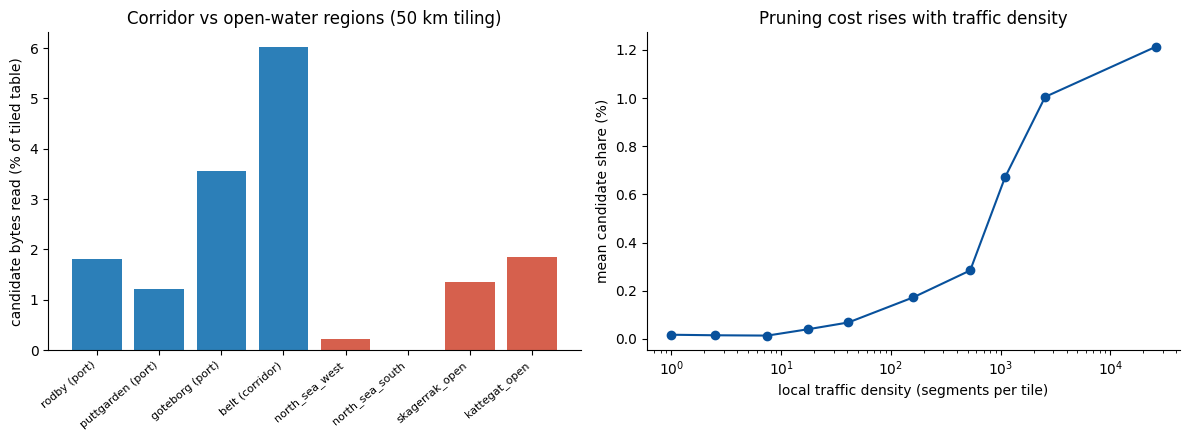

In [5]:
fig,(a1,a2)=plt.subplots(1,2,figsize=(12,4.5))
cols=["#2c7fb8" if k=="corridor" else "#d6604d" for k in named["kind"]]
a1.bar(range(len(named)),named["candidate_share_pct"],color=cols)
a1.set_xticks(range(len(named))); a1.set_xticklabels(named["region"],rotation=40,ha="right",fontsize=8)
a1.set_ylabel("candidate bytes read (% of tiled table)")
a1.set_title(f"Corridor vs open-water regions ({TILE_M//1000} km tiling)")
a1.spines[["top","right"]].set_visible(False)
a2.plot(dec.groupby("decile").apply(lambda g:(g["density_min"].iloc[0]+g["density_max"].iloc[0])/2),
        dec["mean_share_pct"],"o-",color="#08519c")
a2.set_xscale("log"); a2.set_xlabel("local traffic density (segments per tile)")
a2.set_ylabel("mean candidate share (%)"); a2.set_title("Pruning cost rises with traffic density")
a2.spines[["top","right"]].set_visible(False)
plt.tight_layout(); plt.show()

### Map: where each region sits on the traffic density surface

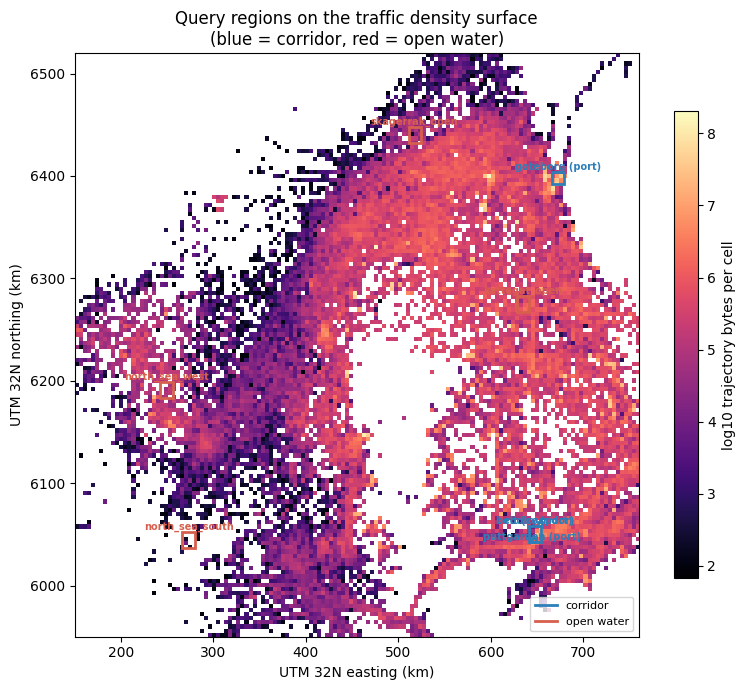

In [6]:
X0,X1,Y0,Y1 = 150000, 760000, 5950000, 6520000   # window covering all regions
NB=140; sx=(X1-X0)/NB; sy=(Y1-Y0)/NB
g=con.execute(f'''SELECT floor((cx0-{X0})/{sx}) bx, floor((cy0-{Y0})/{sy}) byb, sum(w) ws
  FROM bounds WHERE cx0 BETWEEN {X0} AND {X1} AND cy0 BETWEEN {Y0} AND {Y1} GROUP BY 1,2''').fetchall()
grid=np.full((NB,NB),np.nan)
for bx,by,ws in g:
    if 0<=bx<NB and 0<=by<NB: grid[int(by),int(bx)]=np.log10(ws)
fig,ax=plt.subplots(figsize=(8,7))
im=ax.imshow(grid,origin="lower",extent=[X0/1000,X1/1000,Y0/1000,Y1/1000],cmap="magma",aspect="auto")
plt.colorbar(im,ax=ax,shrink=0.8,label="log10 trajectory bytes per cell")
for kind,regs in [("corridor",CORRIDOR),("open_water",OPEN_WATER)]:
    c="#2c7fb8" if kind=="corridor" else "#d6604d"
    for name,(x0,y0,x1,y1) in regs.items():
        ax.add_patch(Rectangle((x0/1000,y0/1000),max((x1-x0)/1000,4),max((y1-y0)/1000,4),
                     fill=False,edgecolor=c,lw=2))
        ax.annotate(name,((x0+x1)/2000,y1/1000),color=c,fontsize=7,ha="center",va="bottom",weight="bold")
ax.set_xlabel("UTM 32N easting (km)"); ax.set_ylabel("UTM 32N northing (km)")
ax.set_title("Query regions on the traffic density surface\n(blue = corridor, red = open water)")
ax.plot([],[],color="#2c7fb8",lw=2,label="corridor"); ax.plot([],[],color="#d6604d",lw=2,label="open water")
ax.legend(loc="lower right",fontsize=8); plt.tight_layout(); plt.show()